In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sympy.physics.quantum.dagger import Dagger
import math
import random
from itertools import product
import cmath
from sympy import I, Matrix, symbols
from sympy.physics.quantum import TensorProduct
import pandas as pd
from IPython.display import clear_output
import matplotlib.colors as mcolors
import Hamiltonian
import build_H

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = 'cpu'

In [4]:
device

device(type='cuda')

In [85]:
number_of_qubits = 10

tensor(-4.4024)


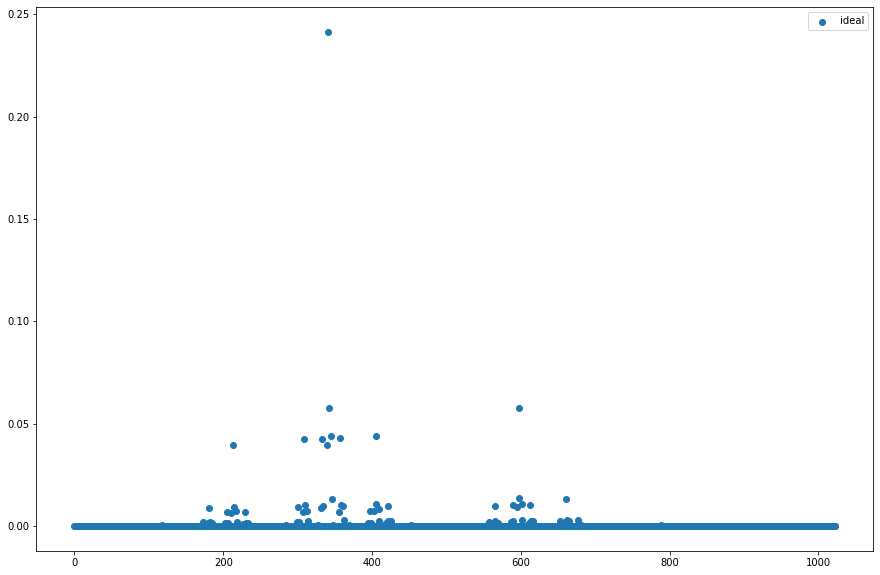

In [86]:
basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        basis[r][i] = float(p[i])
    r -= 1

m = 0.1
H = Hamiltonian.Get_H(m, number_of_qubits)
eig_values = torch.eig(H, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(H, eigenvectors = True)[1]
c = eig_values.min()
k = torch.min(eig_values,0)[1]
R = eig_vector[:,k].reshape(2**number_of_qubits)
distr = R**2
distr = distr.view(2**number_of_qubits, 1)
print(c)
x = np.arange(0,2**number_of_qubits)
fig, ax = plt.subplots(figsize = (15,10))
ax.scatter(x, distr, alpha = 1, label='ideal')
ax.legend()
plt.show()

In [87]:
a = torch.zeros(2**number_of_qubits)
b = torch.zeros(2**number_of_qubits)
c = torch.zeros(2**number_of_qubits)
i = torch.arange(0, 256,1)
j = torch.arange(256, 512,1)
k = torch.arange(512, 1024,1)
a[i] = R[i]
b[j] = R[j]
c[k] = R[k]


In [88]:
print(a.norm(),b.norm(), c.norm())

tensor(0.3230) tensor(0.8466) tensor(0.4229)


In [8]:
a = a/a.norm()
b = b/b.norm()
c = c/c.norm()

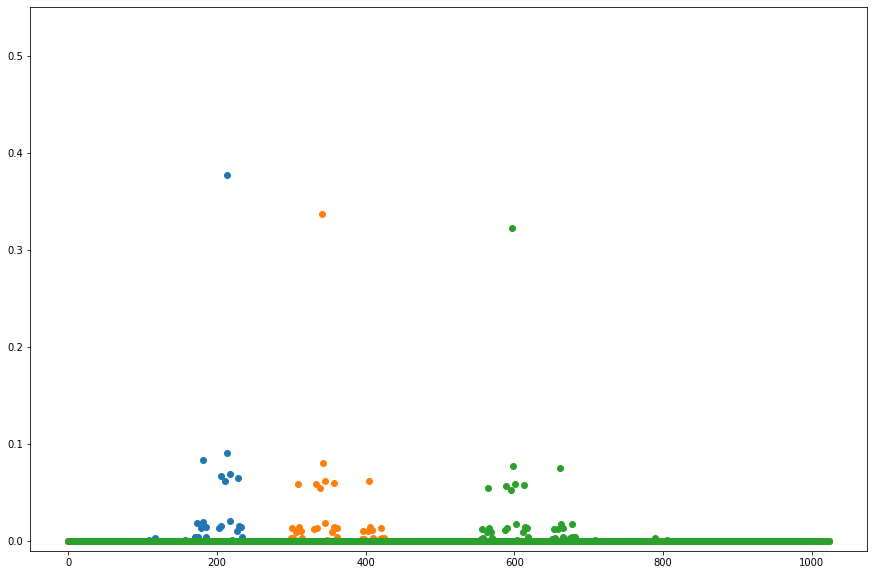

In [9]:
fig, ax = plt.subplots(figsize = (15,10))
ax.scatter(x, a**2, alpha = 1, label='ideal')
ax.scatter(x, b**2, alpha = 1, label='ideal')
ax.scatter(x, c**2, alpha = 1, label='ideal')
ax.set_ylim(-0.01, 0.55)
plt.show()

In [10]:
q = a.dot(torch.mm(H,a.view(-1,1)).view(-1))
w = a.dot(torch.mm(H,b.view(-1,1)).view(-1))
e = a.dot(torch.mm(H,c.view(-1,1)).view(-1))
r = b.dot(torch.mm(H,a.view(-1,1)).view(-1))
t = b.dot(torch.mm(H,b.view(-1,1)).view(-1))
y = b.dot(torch.mm(H,c.view(-1,1)).view(-1))
u = c.dot(torch.mm(H,a.view(-1,1)).view(-1))
o = c.dot(torch.mm(H,b.view(-1,1)).view(-1))
p = c.dot(torch.mm(H,c.view(-1,1)).view(-1))
print(q)

tensor(-1.9829)


In [11]:
HH = torch.tensor([[q,w,e],[r,t,y],[u,o,p]])
print(HH)

tensor([[-1.9829, -0.9231,  0.0000],
        [-0.9231, -3.5530, -0.9952],
        [ 0.0000, -0.9952, -2.4103]])


In [12]:
eig_values = torch.eig(HH, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(HH, eigenvectors = True)[1]
c = eig_values.min()
k = torch.min(eig_values,0)[1]
R = eig_vector[:,k].reshape(-1)
print(c,R)

tensor(-4.4024) tensor([0.3230, 0.8466, 0.4229])


In [13]:
number_of_qubits = 8

tensor(-3.4595)


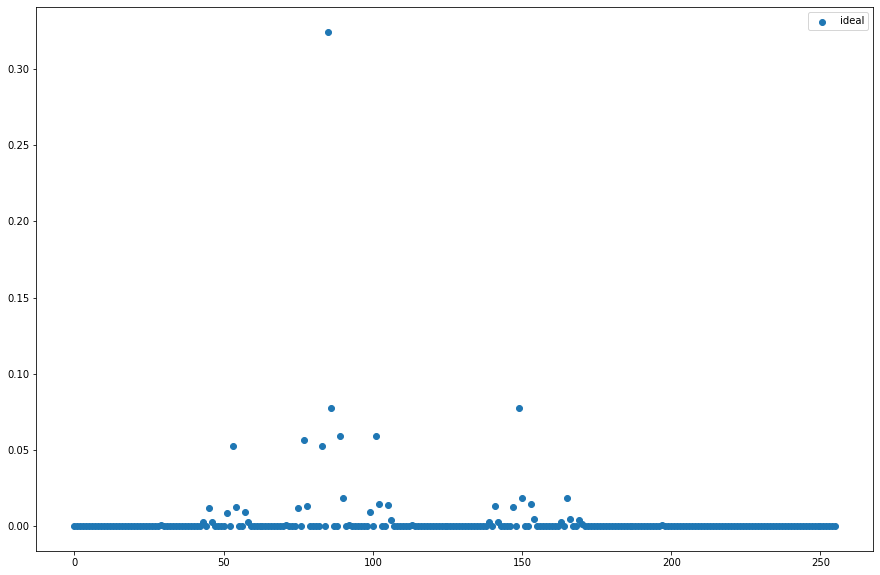

In [14]:
basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        basis[r][i] = float(p[i])
    r -= 1

m = 0.1
H = Hamiltonian.Get_H(m, number_of_qubits)
eig_values = torch.eig(H, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(H, eigenvectors = True)[1]
c = eig_values.min()
k = torch.min(eig_values,0)[1]
R = eig_vector[:,k].reshape(2**number_of_qubits)
distr = R**2
distr = distr.view(2**number_of_qubits, 1)
print(c)
x = np.arange(0,2**number_of_qubits)
fig, ax = plt.subplots(figsize = (15,10))
ax.scatter(x, distr, alpha = 1, label='ideal')
ax.legend()
plt.show()

In [15]:
a = torch.zeros(2**number_of_qubits)
b = torch.zeros(2**number_of_qubits)
c = torch.zeros(2**number_of_qubits)
i = torch.arange(0, 64,1)
j = torch.arange(64, 128,1)
k = torch.arange(128, 256,1)
a[i] = R[i]
b[j] = R[j]
c[k] = R[k]

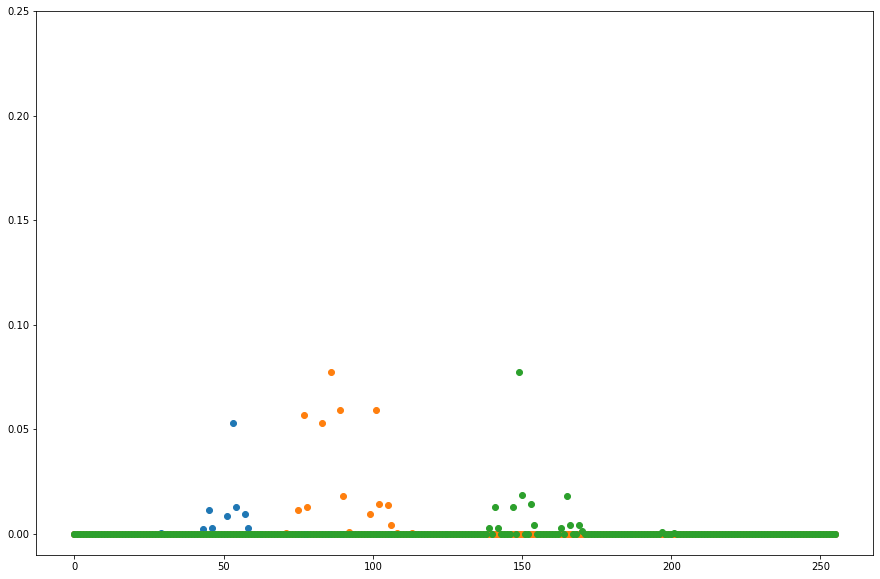

In [16]:
fig, ax = plt.subplots(figsize = (15,10))
ax.scatter(x, a**2, alpha = 1, label='ideal')
ax.scatter(x, b**2, alpha = 1, label='ideal')
ax.scatter(x, c**2, alpha = 1, label='ideal')
ax.set_ylim(-0.01, 0.25)
plt.show()

In [17]:
a = a/a.norm()
b = b/b.norm()
c = c/c.norm()

In [18]:
q = a.dot(torch.mm(H,a.view(-1,1)).view(-1))
w = a.dot(torch.mm(H,b.view(-1,1)).view(-1))
e = a.dot(torch.mm(H,c.view(-1,1)).view(-1))
r = b.dot(torch.mm(H,a.view(-1,1)).view(-1))
t = b.dot(torch.mm(H,b.view(-1,1)).view(-1))
y = b.dot(torch.mm(H,c.view(-1,1)).view(-1))
u = c.dot(torch.mm(H,a.view(-1,1)).view(-1))
o = c.dot(torch.mm(H,b.view(-1,1)).view(-1))
p = c.dot(torch.mm(H,c.view(-1,1)).view(-1))
print(q)

tensor(-1.0366)


In [19]:
HH8 = torch.tensor([[q,w,e],[r,t,y],[u,o,p]])
print(HH8)
print(HH)

tensor([[-1.0366, -0.9226,  0.0000],
        [-0.9226, -2.6107, -0.9952],
        [ 0.0000, -0.9952, -1.4685]])
tensor([[-1.9829, -0.9231,  0.0000],
        [-0.9231, -3.5530, -0.9952],
        [ 0.0000, -0.9952, -2.4103]])


In [20]:
eig_values = torch.eig(HH8, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(HH8, eigenvectors = True)[1]
c = eig_values.min()
k = torch.min(eig_values,0)[1]
R = eig_vector[:,k].reshape(-1)
print(c,R)

tensor(-3.4594) tensor([0.3224, 0.8467, 0.4232])


In [21]:
HH8 - HH

tensor([[9.4636e-01, 5.6255e-04, 0.0000e+00],
        [5.6255e-04, 9.4231e-01, 5.4598e-05],
        [0.0000e+00, 5.4598e-05, 9.4173e-01]])

In [22]:
number_of_qubits = 12

tensor(-5.3456)


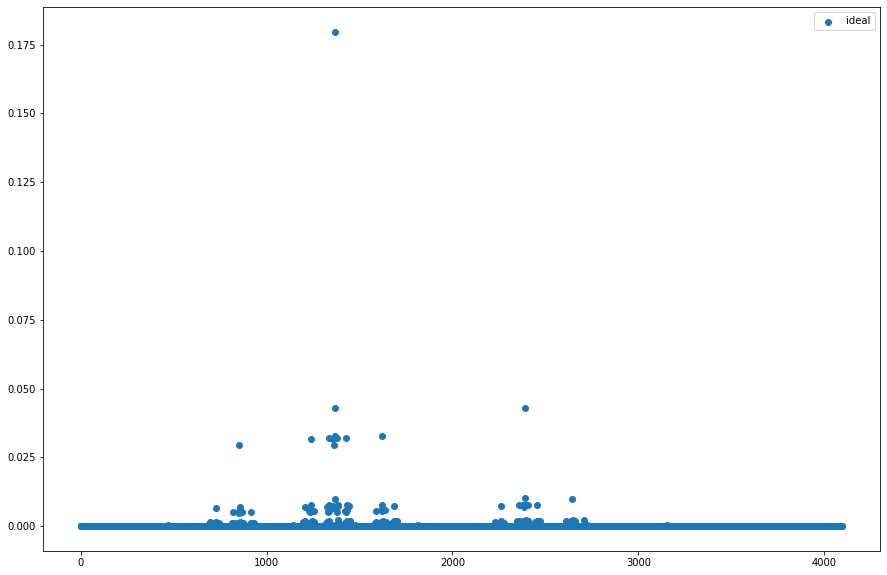

In [23]:
basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        basis[r][i] = float(p[i])
    r -= 1

m = 0.1
H = Hamiltonian.Get_H(m, number_of_qubits)
eig_values, eig_vector = torch.eig(H, eigenvectors = True)
eig_values = eig_values[:,0]
#eig_vector = torch.eig(H, eigenvectors = True)[1]
c = eig_values.min()
k = torch.min(eig_values,0)[1]
R = eig_vector[:,k].reshape(2**number_of_qubits)
distr = R**2
distr = distr.view(2**number_of_qubits, 1)
print(c)
x = np.arange(0,2**number_of_qubits)
fig, ax = plt.subplots(figsize = (15,10))
ax.scatter(x, distr, alpha = 1, label='ideal')
ax.legend()
plt.show()

In [24]:
a = torch.zeros(2**number_of_qubits)
b = torch.zeros(2**number_of_qubits)
c = torch.zeros(2**number_of_qubits)
i = torch.arange(0, 1024,1)
j = torch.arange(1024, 1024 + 1024,1)
k = torch.arange(2048, 2048+2048,1)
a[i] = R[i]
b[j] = R[j]
c[k] = R[k]

In [25]:
a = a/a.norm()
b = b/b.norm()
c = c/c.norm()

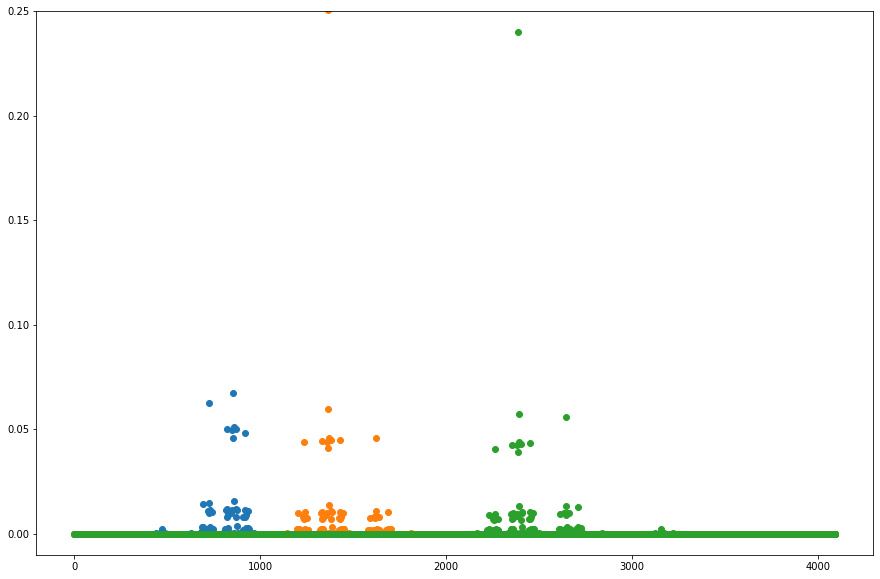

In [26]:
fig, ax = plt.subplots(figsize = (15,10))
ax.scatter(x, a**2, alpha = 1, label='ideal')
ax.scatter(x, b**2, alpha = 1, label='ideal')
ax.scatter(x, c**2, alpha = 1, label='ideal')
ax.set_ylim(-0.01, 0.25)
plt.show()

In [27]:
q = a.dot(torch.mm(H,a.view(-1,1)).view(-1))
w = a.dot(torch.mm(H,b.view(-1,1)).view(-1))
e = a.dot(torch.mm(H,c.view(-1,1)).view(-1))
r = b.dot(torch.mm(H,a.view(-1,1)).view(-1))
t = b.dot(torch.mm(H,b.view(-1,1)).view(-1))
y = b.dot(torch.mm(H,c.view(-1,1)).view(-1))
u = c.dot(torch.mm(H,a.view(-1,1)).view(-1))
o = c.dot(torch.mm(H,b.view(-1,1)).view(-1))
p = c.dot(torch.mm(H,c.view(-1,1)).view(-1))
print(q)

tensor(-2.9266)


In [28]:
HH12 = torch.tensor([[q,w,e],[r,t,y],[u,o,p]])
print(HH12)
print(HH)

tensor([[-2.9266, -0.9232,  0.0000],
        [-0.9232, -4.4960, -0.9952],
        [ 0.0000, -0.9952, -3.3532]])
tensor([[-1.9829, -0.9231,  0.0000],
        [-0.9231, -3.5530, -0.9952],
        [ 0.0000, -0.9952, -2.4103]])


In [29]:
eig_values = torch.eig(HH12, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(HH12, eigenvectors = True)[1]
c = eig_values.min()
k = torch.min(eig_values,0)[1]
R = eig_vector[:,k].reshape(-1)
print(c,R)

tensor(-5.3455) tensor([0.3231, 0.8466, 0.4229])


In [30]:
HH - HH12

tensor([[9.4365e-01, 9.1195e-05, 0.0000e+00],
        [9.1195e-05, 9.4298e-01, 8.7023e-06],
        [0.0000e+00, 8.7023e-06, 9.4289e-01]])

In [31]:
HH8 - HH

tensor([[9.4636e-01, 5.6255e-04, 0.0000e+00],
        [5.6255e-04, 9.4231e-01, 5.4598e-05],
        [0.0000e+00, 5.4598e-05, 9.4173e-01]])

In [32]:
print(HH12)
print(HH)
print(HH8)

tensor([[-2.9266, -0.9232,  0.0000],
        [-0.9232, -4.4960, -0.9952],
        [ 0.0000, -0.9952, -3.3532]])
tensor([[-1.9829, -0.9231,  0.0000],
        [-0.9231, -3.5530, -0.9952],
        [ 0.0000, -0.9952, -2.4103]])
tensor([[-1.0366, -0.9226,  0.0000],
        [-0.9226, -2.6107, -0.9952],
        [ 0.0000, -0.9952, -1.4685]])


In [89]:
number_of_qubits = 14


16384
torch.Size([3432, 1])


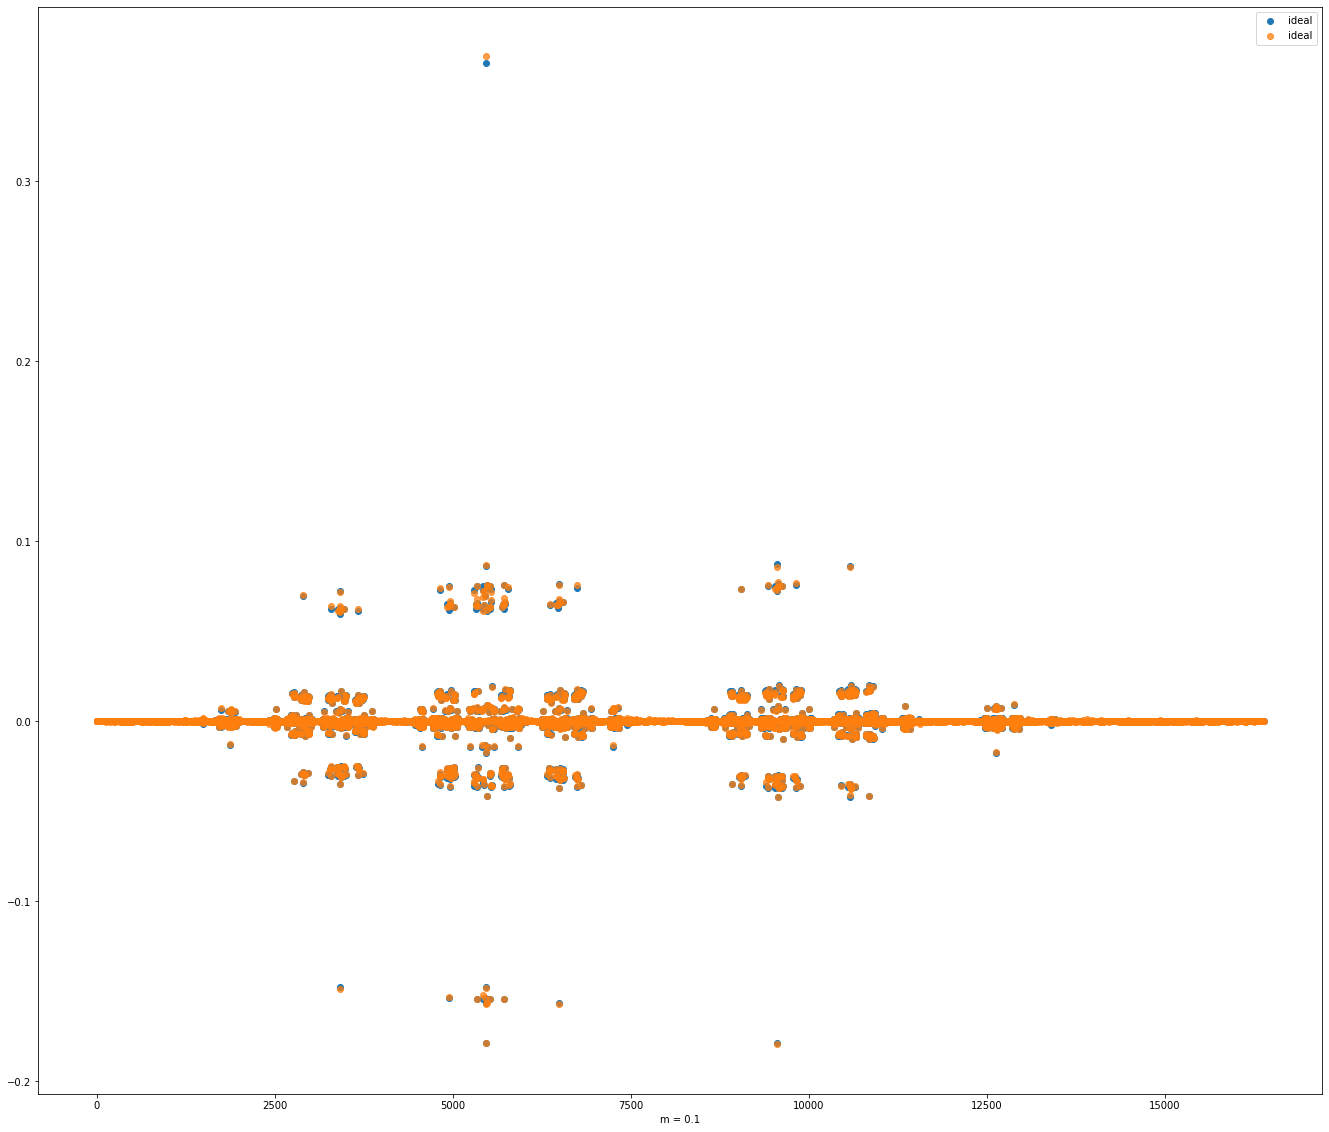

In [116]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_14 (1).npy')).float()
z = torch.tensor(np.load('number_of_qubits_14.npy')).float()
print(2**14)
print(eigenvectors.shape)
i = torch.arange(eigenvectors.shape[0])
my_way14 = torch.zeros(2**14)
x = torch.arange(2**14)
#my_way14 = eigenvectors
my_way14[good_vectors] = eigenvectors[i,0]
fig, ax = plt.subplots(figsize = (23,20))
ax.scatter(x, my_way14, alpha = 1, label='ideal')
ax.scatter(x, z, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

16384
torch.Size([3432, 1])


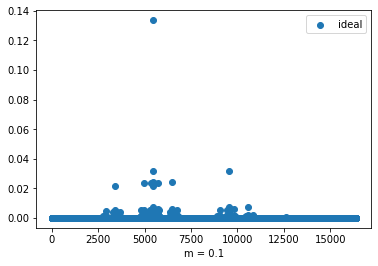

In [96]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_14 (1).npy')).float()
print(2**14)
print(eigenvectors.shape)
i = torch.arange(eigenvectors.shape[0])
my_way14 = torch.zeros(2**14)
x = torch.arange(2**14)
#my_way14 = eigenvectors
my_way14[good_vectors] = eigenvectors[i,0]
fig, ax = plt.subplots()
ax.scatter(x, my_way14**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

In [94]:
basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        basis[r][i] = float(p[i])
    r -= 1

m = 0.1

sum_spin = math.ceil((number_of_qubits - 1) / 2 )
print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
#print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch


7
torch.Size([3432]) torch.Size([3432])


In [97]:
R = my_way14.reshape(-1)
a = torch.zeros(2**number_of_qubits)
b = torch.zeros(2**number_of_qubits)
c = torch.zeros(2**number_of_qubits)
i = torch.arange(0, 4096,1)
j = torch.arange(4096, 8192 ,1)
k = torch.arange(8192, 12288+2048 + 2048,1)
a[i] = R[i]
b[j] = R[j]
c[k] = R[k]

In [98]:
print(a.norm(), b.norm(), c.norm())

tensor(0.3231) tensor(0.8466) tensor(0.4229)


In [99]:
a = a/a.norm()
b = b/b.norm()
c = c/c.norm()


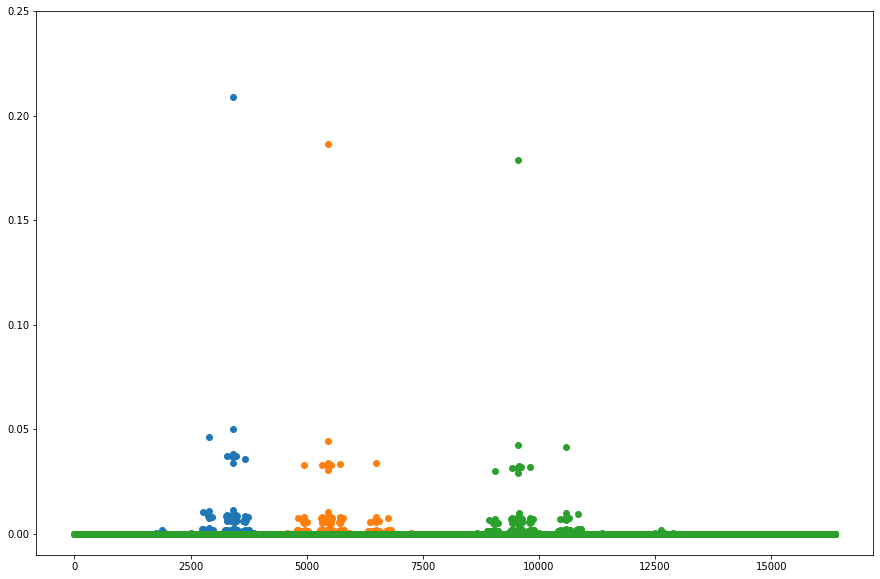

In [100]:
fig, ax = plt.subplots(figsize = (15,10))
ax.scatter(x, a**2, alpha = 1, label='ideal')
ax.scatter(x, b**2, alpha = 1, label='ideal')
ax.scatter(x, c**2, alpha = 1, label='ideal')
ax.set_ylim(-0.01, 0.25)
plt.show()

In [101]:
batch1 = basis[0: 4096].reshape(-1, number_of_qubits)
H1 = build_H.matrix(batch1, m, number_of_qubits)

batch2 = basis[4096:8192 ].reshape(-1, number_of_qubits)
H2 = build_H.matrix(batch2, m, number_of_qubits)

batch3 = basis[8192: 12288 + 2048].reshape(-1, number_of_qubits)
H3 = build_H.matrix(batch3, m, number_of_qubits)

In [102]:
12288 + 2048

14336

In [103]:
q = a[0: 4096].dot(torch.mm(H1,a[0: 4096].view(-1,1)).view(-1))
t = b[4096:8192 ].dot(torch.mm(H2,b[4096:8192 ].view(-1,1)).view(-1))
print(H3.shape, c.shape)
#torch.mm(H3,c[8192: 14336])
p = c[8192: 12288 + 2048].dot(torch.mm(H3,c[8192: 12288 + 2048].view(-1,1)).view(-1))

torch.Size([6144, 6144]) torch.Size([16384])


In [104]:
HH14 = torch.tensor([[q,-0.9232,0],[-0.9232,t,-0.9952],[0,-0.9952,p]])
print(HH14)
#print(HH)

tensor([[-3.8698, -0.9232,  0.0000],
        [-0.9232, -5.4391, -0.9952],
        [ 0.0000, -0.9952, -4.2962]])


In [105]:
eig_values = torch.eig(HH14, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(HH14, eigenvectors = True)[1]
c = eig_values.min()
k = torch.min(eig_values,0)[1]
R = eig_vector[:,k].reshape(-1)
print(c, -6.2886, R)
print(R.norm())
print(eig_values)

tensor(-6.2886) -6.2886 tensor([0.3231, 0.8466, 0.4229])
tensor(1.0000)
tensor([-6.2886, -3.2167, -4.0999])


In [52]:
print(HH12)

tensor([[-2.9266, -0.9232,  0.0000],
        [-0.9232, -4.4960, -0.9952],
        [ 0.0000, -0.9952, -3.3532]])


In [106]:
HH8 - HH

tensor([[9.4636e-01, 5.6255e-04, 0.0000e+00],
        [5.6255e-04, 9.4231e-01, 5.4598e-05],
        [0.0000e+00, 5.4598e-05, 9.4173e-01]])

In [107]:
HH - HH12

tensor([[9.4365e-01, 9.1195e-05, 0.0000e+00],
        [9.1195e-05, 9.4298e-01, 8.7023e-06],
        [0.0000e+00, 8.7023e-06, 9.4289e-01]])

In [108]:
HH12 - HH14

tensor([[ 9.4320e-01, -1.3709e-05,  0.0000e+00],
        [-1.3709e-05,  9.4309e-01, -2.9504e-05],
        [ 0.0000e+00, -2.9504e-05,  9.4307e-01]])

In [109]:
I = torch.eye(3)
I[0,0] *= 0.943
I[1,1] *= 0.943
I[2,2] *= 0.943
print(I)

tensor([[0.9430, 0.0000, 0.0000],
        [0.0000, 0.9430, 0.0000],
        [0.0000, 0.0000, 0.9430]])


In [110]:
HH16 = HH14 - I
eig_values = torch.eig(HH16, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(HH16, eigenvectors = True)[1]
c = eig_values.min()
k = torch.min(eig_values,0)[1]
R = eig_vector[:,k].reshape(-1)
print(c, -7.2317, R)
print(eig_values)

tensor(-7.2316) -7.2317 tensor([0.3231, 0.8466, 0.4229])
tensor([-7.2316, -4.1597, -5.0429])


In [111]:
HH18 = HH16 - I
eig_values = torch.eig(HH18, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(HH18, eigenvectors = True)[1]
c = eig_values.min()
k = torch.min(eig_values,0)[1]
R = eig_vector[:,k].reshape(-1)
print(c,R)
print(eig_values)

tensor(-8.1746) tensor([0.3231, 0.8466, 0.4229])
tensor([-8.1746, -5.1027, -5.9859])


In [112]:
HH20 = HH18 - I
eig_values = torch.eig(HH20, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(HH20, eigenvectors = True)[1]
c = eig_values.min()
k = torch.min(eig_values,0)[1]
R = eig_vector[:,k].reshape(-1)
print(c,R)
print(eig_values)

tensor(-9.1176) tensor([0.3231, 0.8466, 0.4229])
tensor([-9.1176, -6.0457, -6.9289])


In [125]:
HH400 = HH20 - I*190
eig_values = torch.eig(HH40, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(HH40, eigenvectors = True)[1]
c = eig_values.min()
k = torch.min(eig_values,0)[1]
R = eig_vector[:,k].reshape(-1)
print(c/400,R)
print(eig_values)

tensor(-0.0464) tensor([0.3231, 0.8466, 0.4229])
tensor([-18.5476, -15.4757, -16.3589])


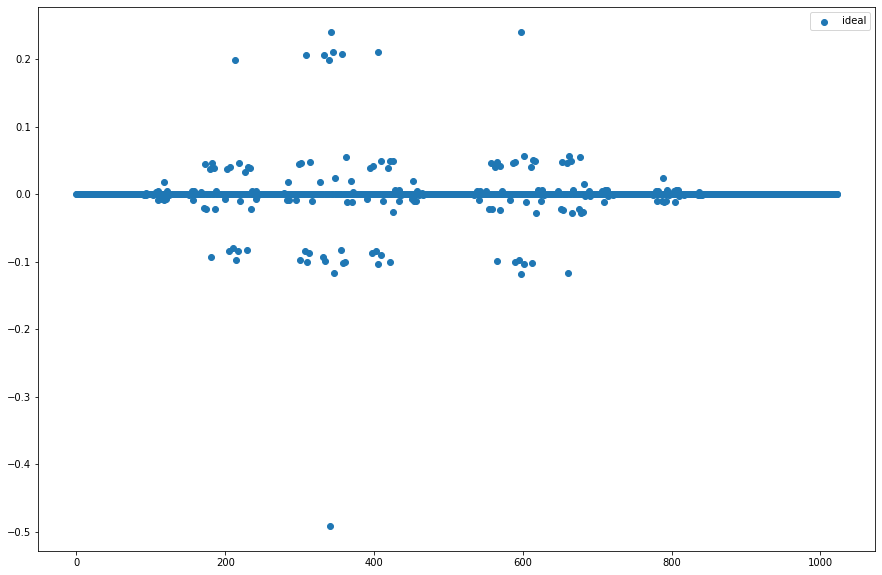

In [134]:
fig, ax = plt.subplots(figsize = (15,10))
ax.scatter(x, R, alpha = 1, label='ideal')
ax.legend()
plt.show()

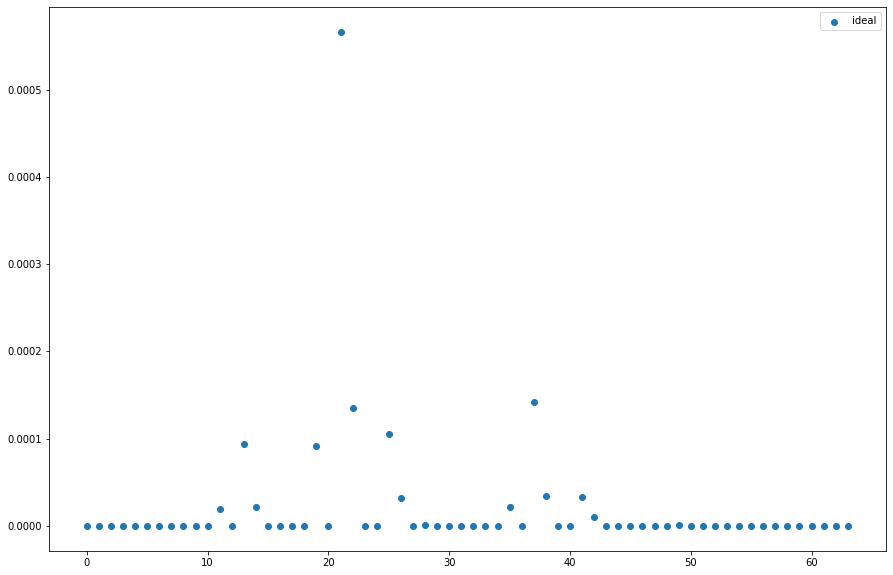

In [141]:
t = R[512+256: 512+256+64]
x = torch.arange(t.shape[0])
fig, ax = plt.subplots(figsize = (15,10))
ax.scatter(x, t**2, alpha = 1, label='ideal')
ax.legend()
plt.show()

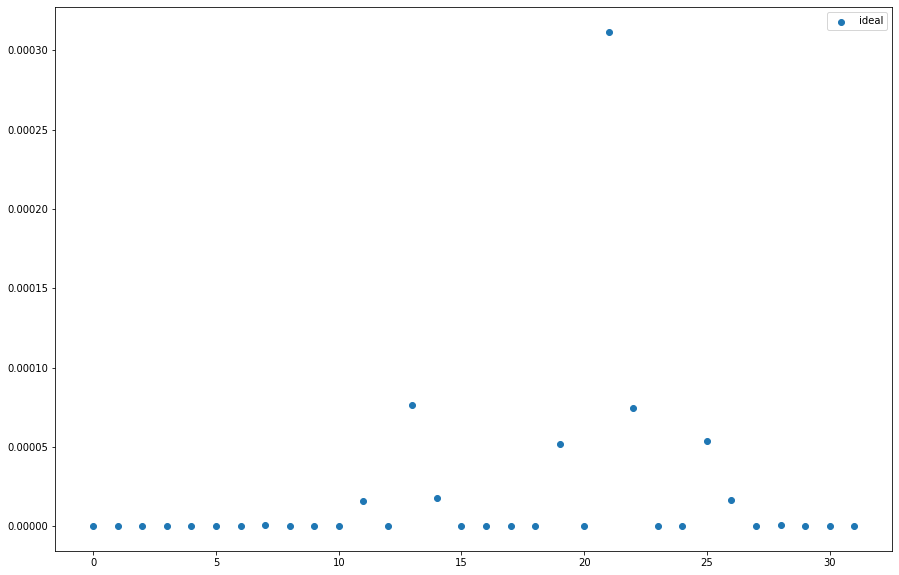

In [143]:
t = R[64 + 32: 128]
x = torch.arange(t.shape[0])
fig, ax = plt.subplots(figsize = (15,10))
ax.scatter(x, t**2, alpha = 1, label='ideal')
ax.legend()
plt.show()